Analyse de 7 couches...
Erreur sur ._1_aligned.txt: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Erreur sur ._2_aligned.txt: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte


,layer_index,filename,mean_z,std_z,min_z,max_z,points_count
0,0,1_aligned.txt,-12.526850,3.830942,-22.87033,-2.07033,31076
1,1,2_aligned.txt,-39.446570,4.963752,-52.92033,-25.92033,33460
2,2,3_aligned.txt,-66.969151,5.533760,-81.57033,-51.57033,33929
3,3,4_aligned.txt,-94.466374,5.410444,-109.02033,-79.02033,33516
4,4,5_aligned.txt,-119.717745,4.996112,-133.47033,-105.67033,31977


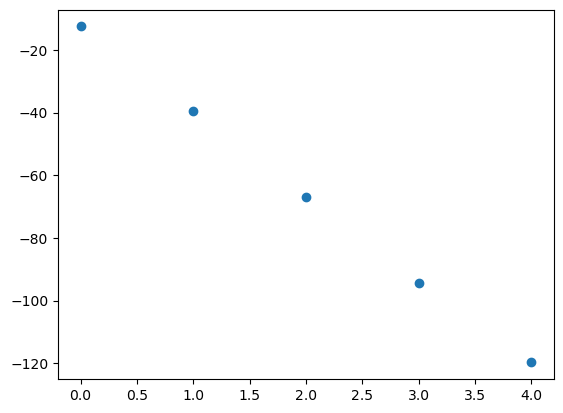

In [27]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
INPUT_DIR = '/Volumes/My Book/data recov/Gocator_Data/ALIGNED/3'
THICKNESS = 0.35

def extract_layer_number(filename):
    """Extrait le numéro de couche pour un tri correct."""
    matches = re.findall(r'\d+', filename)
    return int(matches[-1]) if matches else 0

def analyze_z_topology(input_folder, layer_thickness):
    path = Path(input_folder)


    files = [f for f in path.iterdir() if f.suffix == '.txt']
                   
    
    results = []

    print(f"Analyse de {len(files)} couches...")
    
    for i, filepath in enumerate(files):
        try:
            data = np.loadtxt(filepath)
            if data.size == 0: continue
            if data.ndim == 1: data = data.reshape(1, -1)
            
            raw_z = data[:, 2]
            median_offset = (i + 0.5) * layer_thickness
            absolute_z = raw_z + median_offset
            
            results.append({
                'layer_index': i,
                'filename': filepath.name,
                'mean_z': np.mean(absolute_z),
                'std_z': np.std(absolute_z),
                'min_z': np.min(absolute_z),
                'max_z': np.max(absolute_z),
                'points_count': len(absolute_z)
            })
        except Exception as e:
            print(f"Erreur sur {filepath.name}: {e}")

    return pd.DataFrame(results)

df = analyze_z_topology(INPUT_DIR, THICKNESS)

if df is not None:
    display(df.head(10))
    

    
plt.figure()
plt.scatter(df.layer_index,df.mean_z)
plt.show()


In [5]:
import re
from pathlib import Path
import numpy as np
import pandas as pd


In [17]:
input_folder='/Volumes/My Book/data recov/Gocator_Data/ALIGNED/3'
input_path = Path(input_folder)
txt_files = [f for f in input_path.iterdir() if f.is_file() and f.suffix.lower() == '.txt']
p=[]
for file in txt_files:
    doc=np.loadtxt(file)
    p.append(doc)

data= pd.DataFrame(p)
data[0][1]

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte

In [ ]:
for file in data: 
    z=file[]

SyntaxError: invalid syntax (606585039.py, line 1)

In [38]:
import re
from pathlib import Path
import numpy as np
import trimesh
from scipy.spatial import Delaunay, cKDTree



def load_topology_layer(filepath: Path, layer_index: int, layer_thickness: float) -> np.ndarray:
    """
    Load points from a text file and apply Z-offset based on layer thickness and index.
    The local Z coordinate is assumed to be relative to the layer's median plane.
    """
    try:
        data = np.loadtxt(filepath)
    except Exception:
        return None
        
    # if data.size == 0 or data.ndim == 1:
    #     if data.size > 0 and data.ndim == 1:
    #         data = data.reshape(1, -1)
    #     else:
    #         return None
        
    # if data.shape[1] < 3:
    #     return None
        
    points = data.copy()
    # Apply global Z-offset: index * thickness + half-thickness (median plane)
    median_z = (layer_index + 0.5) * layer_thickness
    points[:, 0] += median_z
    # for i in points[:,0]:
    #     if i
    return points

def reconstruct_topology(input_folder: str, thickness: float, output_file: str = "nuage_de_points.ply"):
    """
    Orchestrate the 3D point cloud reconstruction from a directory of topology layer files.
    """
    input_path = Path(input_folder)
    if not input_path.exists() or not input_path.is_dir():
        return
        
    txt_files = [f for f in input_path.iterdir() if f.is_file() and f.suffix.lower() == '.txt']
    if not txt_files:
        return
        
    all_points = []
    
    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    layer_out_dir = Path("sortie/GOCATOR/3")
    layer_out_dir.mkdir(parents=True, exist_ok=True)
    
    for index, filepath in enumerate(txt_files):
        layer_points = load_topology_layer(filepath, index, thickness)
        if layer_points is not None and len(layer_points) > 20:



            #  Statistical Outlier Removal (SOR)
            tree = cKDTree(layer_points)
            distances, _ = tree.query(layer_points, k=21)
            
            avg_distances = np.mean(distances[:, 1:], axis=1)
            
            mean_dist = np.mean(avg_distances)
            std_dist = np.std(avg_distances)
            
            threshold = mean_dist + 2.0 * std_dist
            
            valid_mask = avg_distances <= threshold
            layer_points = layer_points[valid_mask]
            
            all_points.append(layer_points)
            
            couche_nuage = trimesh.points.PointCloud(layer_points)
            couche_nuage.export(str(layer_out_dir / f"couche_nuage_{index}.ply"))
            
            if len(layer_points) >= 3:
                tri = Delaunay(layer_points[:, 0:2])
                mesh = trimesh.Trimesh(vertices=layer_points, faces=tri.simplices, process=True)
                mesh.export(str(layer_out_dir / f"couche_surface_{index}.stl"))
                
    if not all_points:
        return
            
    # Concatenate all layer 
    global_point_cloud = np.vstack(all_points)
    
    cloud = trimesh.points.PointCloud(global_point_cloud)
    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    try:
        cloud.export(str(output_path))
    except Exception:
        pass


        

INPUT_DIR = '/Volumes/My Book/data recov/Gocator_Data/ALIGNED/3'
LAYER_THICKNESS = 0.4
OUTPUT_PATH = '/Users/aiminemeddeb/Documents/3D TWIN/3D-digital-twin/sortie/GOCATOR/3/nuage_de_points2.ply'
    



In [ ]:
points =load_topology_layer('/Volumes/My Book/data recov/Gocator_Data/ALIGNED/3/1_aligned.txt',0 , 0.4)
print(points)


[[-6.14954160e+02  2.54025974e+03 -3.04533000e+00]
 [-6.11620830e+02  2.54025974e+03 -3.84533000e+00]
 [-6.08287490e+02  2.54025974e+03 -4.44533000e+00]
 ...
 [-6.21620830e+02  1.88025974e+03 -7.04533000e+00]
 [-6.18287490e+02  1.88025974e+03 -5.04533000e+00]
 [-6.04954160e+02  1.87692641e+03 -2.24533000e+00]]
<class 'numpy.ndarray'>
